In [11]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [17]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
from collections import defaultdict

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be adjusted by the LLM
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be adjusted by the LLM
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration # NEW: Track when it was last improved

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance (unchanged)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS 
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0 # NEW
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration # NEW
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS 
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: ENHANCED LOCAL SEARCH 
# =========================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

# =========================================================================
# PART 4.5: HELPER FUNCTIONS FOR ADAPTIVE STRATEGY AND V8
# =========================================================================

cdef double calculate_archive_diversity(pop *archive):
    if archive == NULL or archive.size <= 1:
        return 0.0
    cdef int i, j
    cdef int n = archive.size
    cdef double total_distance = 0.0
    cdef int count = 0
    cdef double x1, y1, x2, y2, dist
    for i in range(n):
        x1 = archive.ind_array[i].f[0]
        y1 = archive.ind_array[i].f[1]
        for j in range(i + 1, n):
            x2 = archive.ind_array[j].f[0]
            y2 = archive.ind_array[j].f[1]
            dist = ((x1 - x2)**2 + (y1 - y2)**2)**0.5
            total_distance += dist
            count += 1
    if count == 0:
        return 0.0
    return total_distance / count

cdef double calculate_archive_hypervolume(pop *archive):
    if archive == NULL or archive.size == 0:
        return 0.0
    points = []
    cdef int i
    for i in range(archive.size):
        points.append((archive.ind_array[i].f[0], archive.ind_array[i].f[1]))
    if not points:
        return 0.0
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    points.sort(key=lambda p: p[0])
    cdef double hv = 0.0
    cdef int j
    for j in range(len(points) - 1):
        x1, y1 = points[j]
        x2, y2 = points[j + 1]
        hv += (x2 - x1) * (ref_y - y1)
    if points:
        x_last, y_last = points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    return hv

cdef dict extract_solution_data_for_python(ind *solution_ind):
    """Extracts data from a C ind struct into a Python dictionary."""
    cdef int i
    data = {
        'f': [solution_ind.f[i] for i in range(nf)],
        'capa': [solution_ind.capa[i] for i in range(nf)],
        'nombr': solution_ind.nombr,
        'Items': [solution_ind.Items[i] for i in range(ni)]
    }
    return data

# V8 NEW FUNCTION: Create an individual from a list of items
cdef void create_ind_from_item_list(ind *x, list item_list):
    """
    Populates an ind struct based on a list of selected item indices.
    This is the core of the direct LLM crossover.
    """
    cdef int i, item_id
    # Reset the individual
    for i in range(nf):
        x.capa[i] = 0.0
        x.f[i] = 0.0
    for i in range(ni):
        x.Items[i] = 0
    x.nombr = 0
    x.nombr_nonpris = 0

    # Populate from the list
    for item_id in item_list:
        if 0 <= item_id < ni:
            x.Items[item_id] = 1
            x.nombr += 1
            for i in range(nf):
                x.capa[i] += weights[i][item_id]
                x.f[i] += profits[i][item_id]

cdef void write_results_to_file(pop *P, output_file, str log_message=""):
    """Write the Pareto front results and a log message to a file."""
    cdef int i, j
    with open(output_file if isinstance(output_file, str) else output_file.decode(), "a") as fpareto:
        if log_message:
            fpareto.write(f"# LOG: {log_message}\n")
        fpareto.write("\n")
        for i in range(P.size):
            for j in range(nf):
                fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
            fpareto.write("\n")
# =========================================================================
# PART 5: ROBUST LLM AGENT AND MAIN EXECUTION FUNCTION (V8)
# =========================================================================

def extract_problem_features_for_llm():
    """Extract meaningful statistical features from the problem instance."""
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    total_capacity = sum(capacities[i] for i in range(nf))
    total_avg_weight = sum(sum(weights[obj][i] for i in range(ni)) for obj in range(nf)) / nf
    capacity_tightness = total_avg_weight / total_capacity if total_capacity > 0 else 0
    profit_variances = []
    weight_variances = []
    for obj in range(nf):
        profits_list = [profits[obj][i] for i in range(ni)]
        weights_list = [weights[obj][i] for i in range(ni)]
        profit_variances.append(np.var(profits_list))
        weight_variances.append(np.var(weights_list))
    features = {
        "num_items": ni, "num_objectives": nf, "capacity_tightness": round(capacity_tightness, 4),
        "avg_profit_variance": round(np.mean(profit_variances), 2),
        "avg_weight_variance": round(np.mean(weight_variances), 2),
    }
    return features

def run_efficient_llm_moacp_v8(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    Run MOACP with the enhanced LLM "Strategist" Agent (V8).
    Features: Direct Crossover, Dual-Parameter Control (L and kappa).
    """
    # All cdef variables must be declared at the top of the function
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int it
    cdef double last_hv = 0.0
    cdef double current_hv
    cdef double last_diversity = 0.0
    cdef double current_diversity
    
    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # --- LLM Agent Definition (V8) ---
    class LLMStrategistV8:
        def __init__(self, model_name="llama3:latest"): 
            self.model_name = model_name
            self.cache = {} 

        def _call_llm_with_json(self, prompt, cache_key):
            if cache_key in self.cache:
                print(f"  [LLM Cache Hit] Using cached response.")
                return self.cache[cache_key]
            print(f"  [LLM Call] Sending prompt to {self.model_name}...")
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt, format='json')
                response_text = response.get('response', '').strip()
                if not response_text:
                    print("  [LLM Error] Empty response. Using default strategy.")
                    return None
                result = json.loads(response_text)
                self.cache[cache_key] = result
                print(f"  [LLM Success] Received valid JSON.")
                return result
            except (json.JSONDecodeError, Exception) as e:
                print(f"  [LLM Error] {e}. Using default strategy.")
                return None

        def get_initial_strategy(self, problem_features):
            cache_key = f"init_{hash(str(problem_features))}"
            prompt = f"""
You are an expert strategist for the Multi-Objective Knapsack Problem. Analyze the problem features and recommend the best initial search strategy.
You control two parameters:
1. 'L': The number of items to try swapping during local search (exploration depth).
2. 'kappa': A selection pressure parameter. Lower kappa favors diverse solutions, higher kappa favors better-performing ones.

Problem Features:
{json.dumps(problem_features, indent=2)}

Respond with a JSON object containing 'strategy_name', 'L_value', 'kappa_value', and 'reasoning'.
Example: {{"strategy_name": "AGGRESSIVE", "L_value": 8, "kappa_value": 0.1, "reasoning": "High tightness requires broad exploration and strong selection."}}
"""
            result = self._call_llm_with_json(prompt, cache_key)
            if result and 'L_value' in result and 'kappa_value' in result:
                print(f"  [LLM Decision] Strategy: {result.get('strategy_name')}, L: {result['L_value']}, kappa: {result['kappa_value']}")
                print(f"  [LLM Reasoning] {result.get('reasoning')}")
                return result['L_value'], result['kappa_value']
            return 5, 0.05

        def get_adaptive_strategy(self, current_iteration, last_hv, current_hv, last_diversity, current_diversity, current_L, current_kappa):
            hv_change = current_hv - last_hv
            diversity_change = current_diversity - last_diversity
            cache_key = f"adaptive_v8_{current_iteration}_{current_hv:.2f}_{current_diversity:.2f}_{current_L}_{current_kappa}"
            prompt = f"""
You are an expert strategist monitoring a multi-objective search.
Iteration: {current_iteration}. Current parameters: L={current_L}, kappa={current_kappa}.
HYPERVOLUME: Was {last_hv:.2f}, now {current_hv:.2f}. Change: {hv_change:.2f}.
DIVERSITY: Was {last_diversity:.2f}, now {current_diversity:.2f}. Change: {diversity_change:.2f}.

Your task is to adjust 'L' and 'kappa'.
- Primary goal: increase hypervolume.
- Secondary goal: maintain or improve diversity.
- If hypervolume stagnates, consider increasing 'L' for more exploration.
- If diversity drops, consider decreasing 'kappa' to allow more diverse solutions.
- If hypervolume is rising steadily, you can slightly increase 'kappa' to focus on better regions.

Respond with a JSON object containing 'new_L_value', 'new_kappa_value', and 'reasoning'.
"""
            result = self._call_llm_with_json(prompt, cache_key)
            if result and 'new_L_value' in result and 'new_kappa_value' in result:
                print(f"  [LLM Adaptive Decision V8] Iteration {current_iteration}: New L={result['new_L_value']}, New kappa={result['new_kappa_value']}")
                print(f"  [LLM Reasoning] {result.get('reasoning')}")
                return result['new_L_value'], result['new_kappa_value']
            print(f"  [LLM Adaptive Decision V8] Iteration {current_iteration}: No change, keeping L={current_L}, kappa={current_kappa}")
            return current_L, current_kappa

        def direct_crossover_with_llm(self, parent1_data, parent2_data):
            cache_key = f"crossover_v8_{hash(str(parent1_data['Items']) + str(parent2_data['Items']))}"
            prompt = f"""
You are an expert solver for the Multi-Objective Knapsack Problem. I will provide you with two good parent solutions. Your task is to generate a NEW, high-quality CHILD solution by combining their strengths.

Parent 1: Items={parent1_data['Items']}, Objectives={parent1_data['f']}
Parent 2: Items={parent2_data['Items']}, Objectives={parent2_data['f']}

The problem has {ni} items, indexed from 0 to {ni-1}.
Analyze the parents. Create a new child solution by selecting a set of items that is a valid, non-dominated combination of the parents.
The child solution MUST be a list of integers.

Respond with a JSON object containing 'child_items' (a list of integers) and 'reasoning'.
Example: {{"child_items": [5, 12, 23, 58, 91, 150, 211, 243], "reasoning": "This combination takes high-profit items from parent 1..."}}
"""
            result = self._call_llm_with_json(prompt, cache_key)
            return result

    # --- Main Execution Loop ---
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    INTERVENTION_INTERVAL = 25
    CROSSOVER_INTERVAL = 50
    
    total_time = 0
    start_time = time.time()
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"\n--- RUN {run}/{NRUNS} ---")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        llm_strategist = LLMStrategistV8() 
        problem_features = extract_problem_features_for_llm()
        print(f"  [Problem Features] {json.dumps(problem_features, indent=4)}")
        
        L, kappa = llm_strategist.get_initial_strategy(problem_features)
        print(f"  [Final Parameters] L={L}, kappa={kappa}")
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        current_log = f"Run {run}: V8 LLM strategy."
        
        it = 0
        while it < NBL:
            # --- Periodic LLM Intervention (V8: Dual Control) ---
            if it > 0 and it % INTERVENTION_INTERVAL == 0:
                print(f"  [Intervention] Pausing at iteration {it} to consult LLM...")
                current_hv = calculate_archive_hypervolume(P)
                current_diversity = calculate_archive_diversity(P)
                L, kappa = llm_strategist.get_adaptive_strategy(it, last_hv, current_hv, last_diversity, current_diversity, L, kappa)
                last_hv = current_hv
                last_diversity = current_diversity

            # --- Direct Crossover Intervention (V8) ---
            elif it > 0 and it % CROSSOVER_INTERVAL == 0:
                print(f"  [Direct Crossover] Pausing at iteration {it} to perform LLM-guided crossover...")
                if P.size > 10:
                    parent1_data = extract_solution_data_for_python(P.ind_array[0])
                    parent2_data = extract_solution_data_for_python(P.ind_array[P.size // 2])
                    crossover_result = llm_strategist.direct_crossover_with_llm(parent1_data, parent2_data)
                    
                    if crossover_result and 'child_items' in crossover_result:
                        print(f"  [LLM Crossover] Reasoning: {crossover_result.get('reasoning')}")
                        child_items = crossover_result['child_items']
                        # Create a new individual from the LLM's list
                        llm_child = create_ind(nf)
                        create_ind_from_item_list(llm_child, child_items)
                        # Evaluate the child to ensure it's valid
                        evaluate(llm_child)
                        # Inject the child into the population by replacing the worst member
                        # This is a simple but effective injection strategy
                        if solutions.size > 0:
                            # Find the worst solution in the current population to replace
                            worst_idx = 0
                            worst_fitness = solutions.ind_array[0].fitness
                            for i in range(solutions.size):
                                if solutions.ind_array[i].fitness < worst_fitness:
                                    worst_fitness = solutions.ind_array[i].fitness
                                    worst_idx = i
                            
                            free_ind(solutions.ind_array[worst_idx])
                            solutions.ind_array[worst_idx] = llm_child
                            print(f"  [LLM Crossover] Injected child solution into population.")
                        else:
                            free_ind(llm_child) # Clean up if no population to inject into

                    else:
                        print("  [LLM Crossover] Failed to generate a valid child solution. Continuing normally.")

            # --- Existing Cython Code ---
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            Indicator_local_search1(solutions, archive, alpha)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        write_results_to_file(P, output_file, current_log)
        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")
    
    # Log runtime to the file for analysis
    with open(output_file, "a") as f:
        f.write(f"# RUNTIME: {total_time:.2f}\n")


            


Content of stdout:
_cython_magic_5668f1d4b6d621410a4a105545e54bb8b62dee4af587aa570e666d393e39623b.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_5668f1d4b6d621410a4a105545e54bb8b62dee4af587aa570e666d393e39623b.c(5659): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_5668f1d4b6d621410a4a105545e54bb8b62dee4af587aa570e666d393e39623b.c(5749): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_5668f1d4b6d621410a4a105545e54bb8b62dee4af587aa570e666d393e39623b.c(6935): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_5668f1d4b6d621410a4a105545e54bb8b62dee4af587aa570e666d393e39623b.c(18141): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal

In [18]:
# =========================================================================
# PART 6: RUN THE ENHANCED EXPERIMENTS (V8)
# =========================================================================

print("Running Enhanced LLM-MOACP V8 on test instances...")
print("This version features direct LLM crossover and dual-parameter control.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_efficient_llm_moacp_v8(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_Strategist_v8.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_efficient_llm_moacp_v8(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Strategist_v8.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_efficient_llm_moacp_v8(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Strategist_v8.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll enhanced experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_Strategist_v8.txt")
print("- 5002_Results_Strategist_v8.txt")
print("- 7502_Results_Strategist_v8.txt")
print("\nYou can now run the final analysis cell to compare the new results.")


Running Enhanced LLM-MOACP V8 on test instances...
This version features direct LLM crossover and dual-parameter control.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 745.59,
    "avg_weight_variance": 693.31
}
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Decision] Strategy: HYBRID, L: 5, kappa: 0.3
  [LLM Reasoning] The problem features suggest a challenging optimization landscape with moderate tightness and profit/weight variance. A hybrid strategy balances exploration and exploitation by setting the local search depth to 5 items (not too shallow or too deep), and selecting solutions based on their overall performance with a moderate selection pressure of 0.3. This approach will allow for some diversification while still favoring better-performing solutio

Starting comprehensive results analysis: Original Baseline vs. LLM-Strategist V8...

--- Analyzing 250-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 212
    Hypervolume: 6614986.88
  LLM-Strategist V8 (Enhanced):
    Pareto Front Size: 202 (-4.72%)
    Hypervolume: 6765304.91 (+2.27%)
    Total Runtime: 1012.19 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V8: 140 / 212 (66.04%)
    V8 points dominated by Baseline: 44 / 202 (21.78%)
  -------------------------------------------------


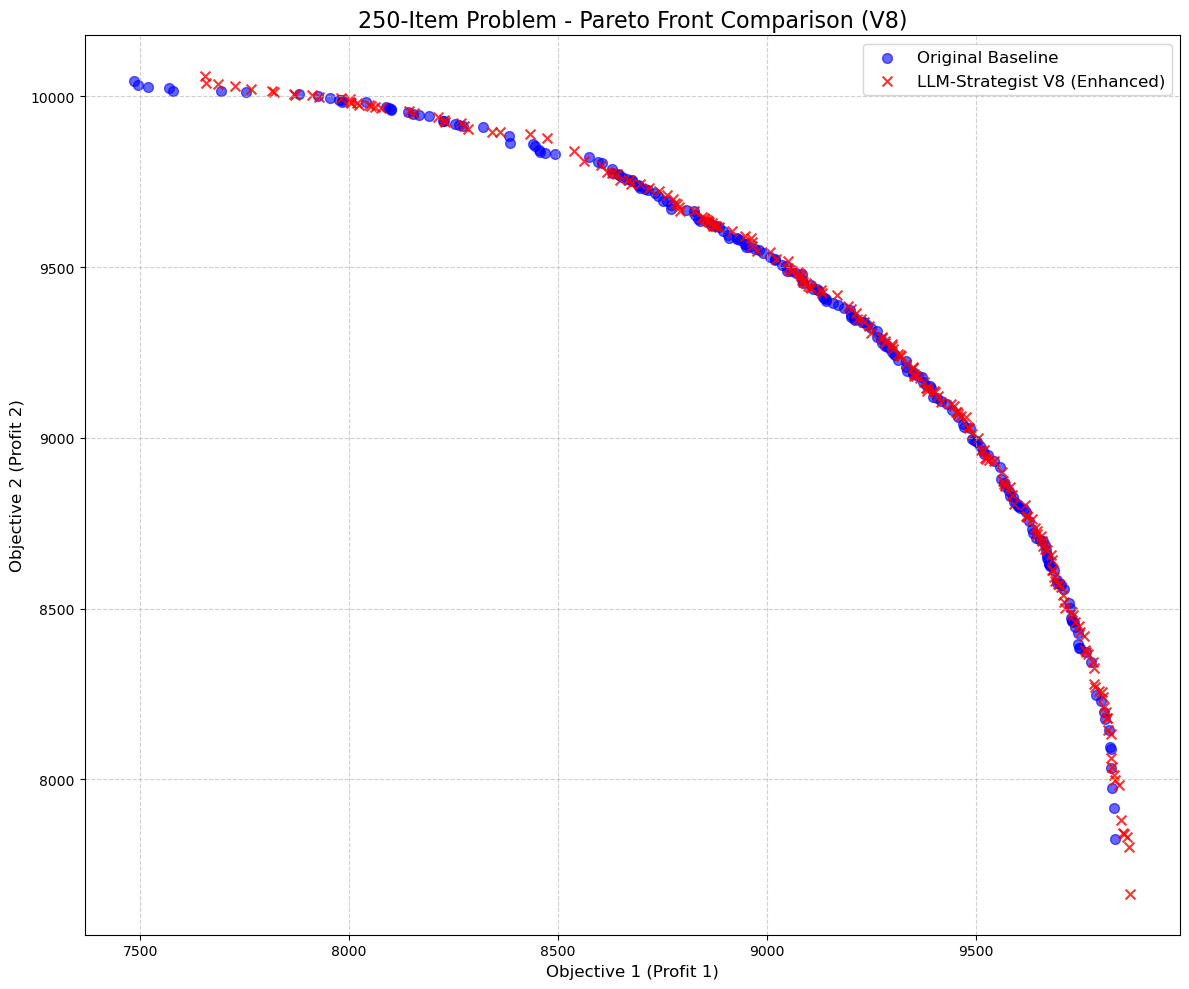


--- Analyzing 500-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 369
    Hypervolume: 23044962.94
  LLM-Strategist V8 (Enhanced):
    Pareto Front Size: 337 (-8.67%)
    Hypervolume: 22738508.00 (-1.33%)
    Total Runtime: 962.74 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V8: 138 / 369 (37.40%)
    V8 points dominated by Baseline: 157 / 337 (46.59%)
  -------------------------------------------------


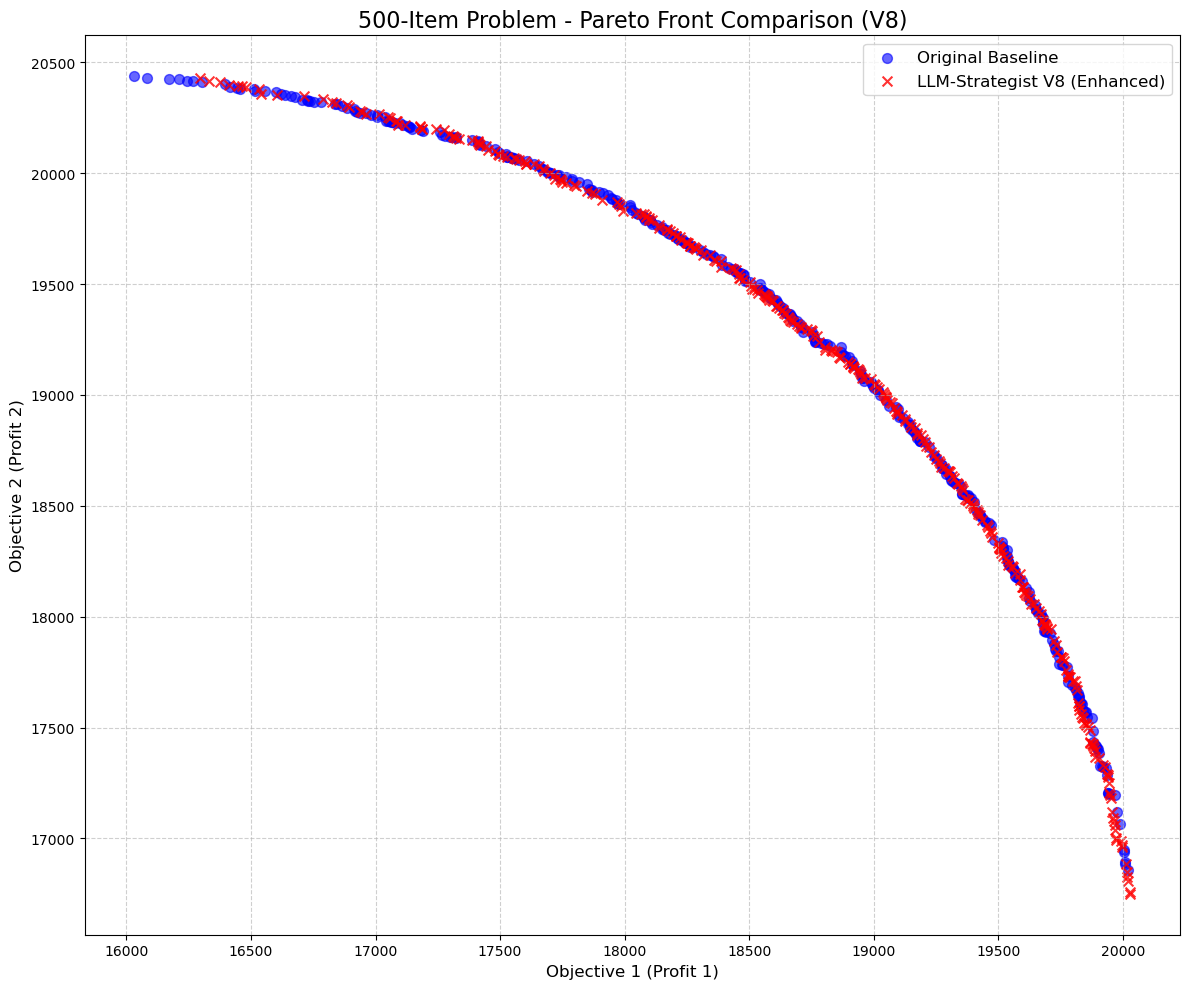


--- Analyzing 750-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 552
    Hypervolume: 56877706.67
  LLM-Strategist V8 (Enhanced):
    Pareto Front Size: 512 (-7.25%)
    Hypervolume: 57322591.50 (+0.78%)
    Total Runtime: 1002.01 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V8: 297 / 552 (53.80%)
    V8 points dominated by Baseline: 218 / 512 (42.58%)
  -------------------------------------------------


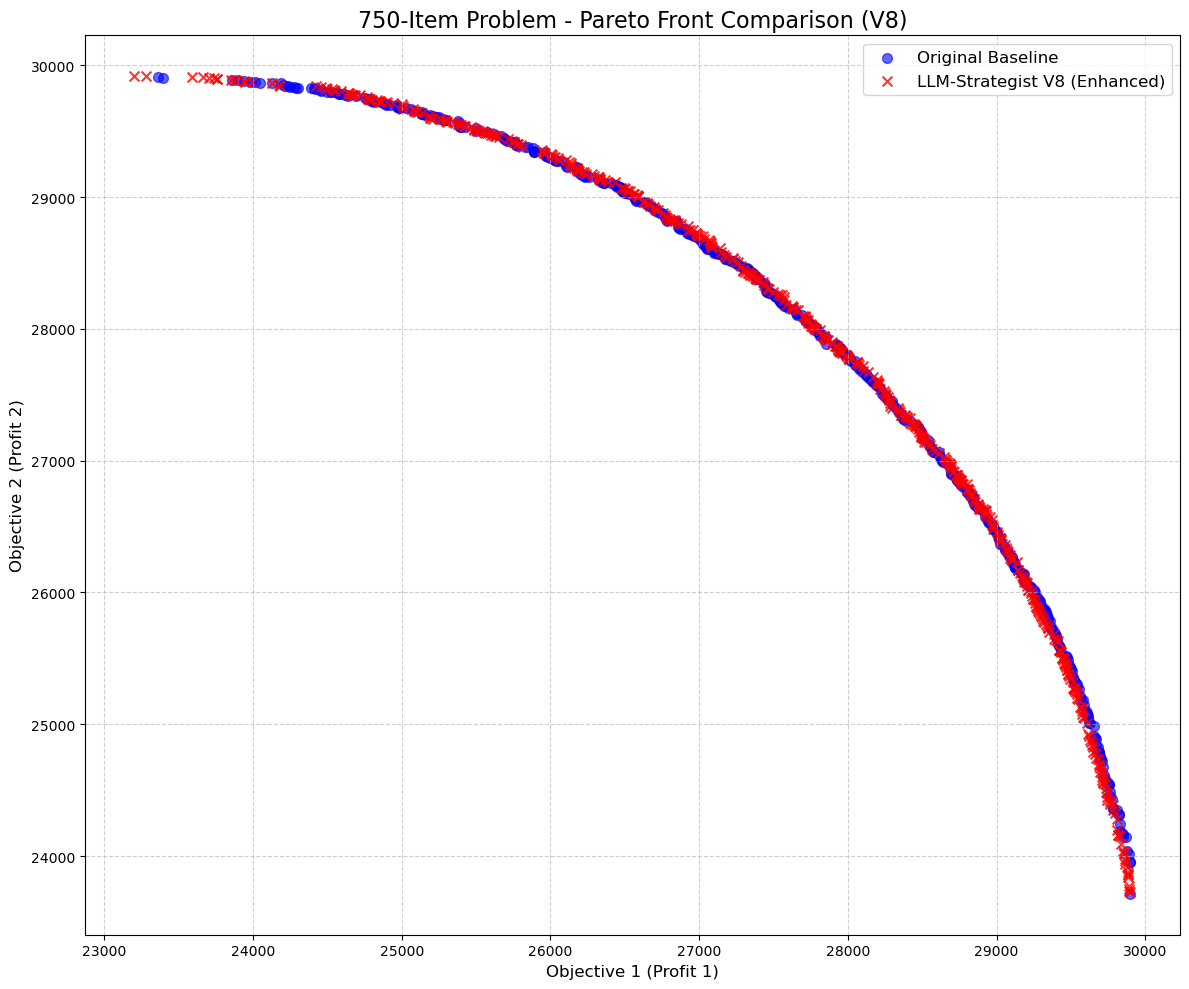


              SUMMARY OF IMPROVEMENTS (V8)

250-Item Problem:
  Hypervolume Improvement: +2.27%
  Dominance Advantage: +44.26%
  V8 Runtime: 1012.19s

500-Item Problem:
  Hypervolume Improvement: -1.33%
  Dominance Advantage: -9.19%
  V8 Runtime: 962.74s

750-Item Problem:
  Hypervolume Improvement: +0.78%
  Dominance Advantage: +11.23%
  V8 Runtime: 1002.01s

------------------------------------------------------------
  AVERAGE HV IMPROVEMENT: +0.57%
  AVERAGE DOMINANCE ADVANTAGE: +15.43%
------------------------------------------------------------

Analysis complete.


In [19]:
# =========================================================================
# PART 7: COMPREHENSIVE RESULTS ANALYSIS (V8 vs. Baseline)
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    sorted_points = sorted(points, key=lambda p: p[0])
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    return hv

def analyze_dominance(baseline_pareto, v8_pareto):
    """Calculate dominance metrics between two Pareto fronts."""
    dominated_baseline_count = 0
    dominated_v8_count = 0
    
    for b_point in baseline_pareto:
        for v_point in v8_pareto:
            if dominates(v_point, b_point):
                dominated_baseline_count += 1
                break
                
    for v_point in v8_pareto:
        for b_point in baseline_pareto:
            if dominates(b_point, v_point):
                dominated_v8_count += 1
                break

    percent_baseline_dominated = (dominated_baseline_count / len(baseline_pareto)) * 100 if baseline_pareto else 0
    percent_v8_dominated = (dominated_v8_count / len(v8_pareto)) * 100 if v8_pareto else 0
    
    return {
        "dominated_baseline_count": dominated_baseline_count,
        "percent_baseline_dominated": percent_baseline_dominated,
        "dominated_v8_count": dominated_v8_count,
        "percent_v8_dominated": percent_v8_dominated
    }

def load_results_and_runtime(filename):
    """Load points and parse runtime from a results file."""
    points = []
    runtime = -1.0
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("# RUNTIME:"):
                try:
                    runtime = float(line.split(":")[1].strip())
                except (IndexError, ValueError):
                    pass
            elif line and not line.startswith("#"):
                try:
                    points.append([float(x) for x in line.split()])
                except ValueError:
                    pass
    return points, runtime

def compare_baseline_vs_v8(original_file, v8_file, title):
    """
    Compare the original baseline results with the new LLM-Strategist V8 results.
    """
    print(f"\n--- Analyzing {title} ---")
    
    # --- Load and Process Results ---
    original_points, _ = load_results_and_runtime(original_file)
    v8_points, v8_runtime = load_results_and_runtime(v8_file)

    if not original_points:
        print(f"  [ERROR] Original file not found or empty: {original_file}")
        return None
    if not v8_points:
        print(f"  [ERROR] V8 file not found or empty: {v8_file}")
        return None

    # --- Calculate Pareto Fronts and Metrics ---
    original_pareto = get_true_pareto_front(original_points)
    v8_pareto = get_true_pareto_front(v8_points)
    
    original_size = len(original_pareto)
    v8_size = len(v8_pareto)
    
    original_hv = calculate_hypervolume(original_pareto)
    v8_hv = calculate_hypervolume(v8_pareto)
    
    # --- Calculate Percentage Improvements ---
    size_improvement = (v8_size - original_size) / original_size * 100 if original_size > 0 else 0
    hv_improvement = (v8_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    # --- Calculate Dominance ---
    dominance_stats = analyze_dominance(original_pareto, v8_pareto)

    # --- Print Results ---
    print(f"  Original Algorithm:")
    print(f"    Pareto Front Size: {original_size}")
    print(f"    Hypervolume: {original_hv:.2f}")
    print(f"  LLM-Strategist V8 (Enhanced):")
    print(f"    Pareto Front Size: {v8_size} ({size_improvement:+.2f}%)")
    print(f"    Hypervolume: {v8_hv:.2f} ({hv_improvement:+.2f}%)")
    if v8_runtime > 0:
        print(f"    Total Runtime: {v8_runtime:.2f} seconds")
    print(f"  -------------------------------------------------")
    print(f"  Dominance Analysis:")
    print(f"    Baseline points dominated by V8: {dominance_stats['dominated_baseline_count']} / {original_size} ({dominance_stats['percent_baseline_dominated']:.2f}%)")
    print(f"    V8 points dominated by Baseline: {dominance_stats['dominated_v8_count']} / {v8_size} ({dominance_stats['percent_v8_dominated']:.2f}%)")
    print(f"  -------------------------------------------------")

    # --- Plotting ---
    plt.figure(figsize=(12, 10))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Baseline")
    if v8_pareto:
        sx, sy = zip(*v8_pareto)
        plt.scatter(sx, sy, color='red', marker='x', s=50, alpha=0.8, label="LLM-Strategist V8 (Enhanced)")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison (V8)", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "title": title,
        "original_size": original_size,
        "v8_size": v8_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "v8_hv": v8_hv,
        "hv_improvement": hv_improvement,
        "v8_runtime": v8_runtime,
        "dominance_stats": dominance_stats
    }

# --- MAIN EXECUTION ---
print("Starting comprehensive results analysis: Original Baseline vs. LLM-Strategist V8...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "2502_ResultsMD.txt",
        "v8": "2502_Results_Strategist_v8.txt",
        "title": "250-Item Problem"
    },
    {
        "original": "5002_ResultsMD.txt",
        "v8": "5002_Results_Strategist_v8.txt",
        "title": "500-Item Problem"
    },
    {
        "original": "7502_ResultsMD.txt",
        "v8": "7502_Results_Strategist_v8.txt",
        "title": "750-Item Problem"
    }
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_v8(
        files["original"], 
        files["v8"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*60)
print("              SUMMARY OF IMPROVEMENTS (V8)")
print("="*60)

if all_results:
    total_hv_improvement = 0
    total_domination_advantage = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        print(f"  Dominance Advantage: {res['dominance_stats']['percent_baseline_dominated'] - res['dominance_stats']['percent_v8_dominated']:+.2f}%")
        if res['v8_runtime'] > 0:
            print(f"  V8 Runtime: {res['v8_runtime']:.2f}s")
        total_hv_improvement += res['hv_improvement']
        total_domination_advantage += (res['dominance_stats']['percent_baseline_dominated'] - res['dominance_stats']['percent_v8_dominated'])

    avg_hv_improvement = total_hv_improvement / len(all_results)
    avg_domination_advantage = total_domination_advantage / len(all_results)
    
    print("\n" + "-"*60)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print(f"  AVERAGE DOMINANCE ADVANTAGE: {avg_domination_advantage:+.2f}%")
    print("-"*60)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")


In [11]:
# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_efficient_llm_moacp_v5(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Strategist_v7.txt")
print("Finished experiment for 500 items.")
print("======================================================")
print("- 5002_Results_Strategist_v7.txt")


Starting experiment for 500 items...

--- RUN 1/10 ---
Instance: 500.2.txt, Items: 500, Objectives: 2
  [Problem Features] {
    "num_items": 500,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 681.29,
    "avg_weight_variance": 672.18
}
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Decision] Strategy: BALANCED, L: 4
  [LLM Reasoning] With a moderate number of items and two objectives, a balanced approach is suitable. The high average profit and weight variances indicate that there may be multiple local optima. A higher L value could lead to overshooting the optimal solution, while a lower L value might not explore enough. A balanced L value of 4 will provide a good balance between exploration and exploitation.
  [Final Parameters] L=4, kappa=0.05
  [Intervention] Pausing at iteration 25 to consult LLM...
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Adaptive

Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...

--- Analyzing 500-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 369
    Hypervolume: 23044962.94
  LLM-Strategist V6 (Adaptive):
    Pareto Front Size: 371 (+0.54%)
    Hypervolume: 23458081.10 (+1.79%)


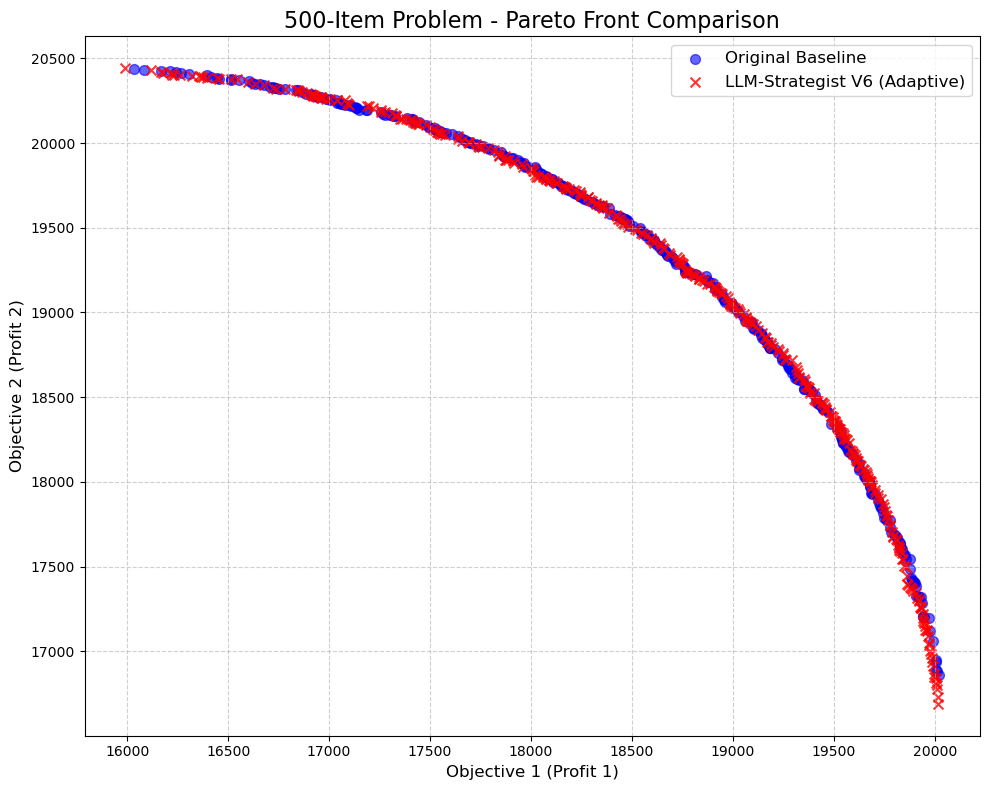


              SUMMARY OF IMPROVEMENTS (V7)

500-Item Problem:
  Hypervolume Improvement: +1.79%

--------------------------------------------------
  AVERAGE HV IMPROVEMENT: +1.79%
--------------------------------------------------

Analysis complete.


In [12]:
# --- MAIN EXECUTION ---
print("Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "5002_ResultsMD.txt",
        "strategist": "5002_Results_Strategist_v7.txt",
        "title": "500-Item Problem"
    },
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_strategist(
        files["original"], 
        files["strategist"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*50)
print("              SUMMARY OF IMPROVEMENTS (V7)")
print("="*50)

if all_results:
    total_hv_improvement = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        total_hv_improvement += res['hv_improvement']

    avg_hv_improvement = total_hv_improvement / len(all_results)
    
    print("\n" + "-"*50)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print("-"*50)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")

Starting advanced dominance analysis: Baseline vs. V7...

--- Advanced Analysis: 500-Item Problem (V7 vs. Baseline) ---
  Baseline Pareto Front Size: 369
  V7 Pareto Front Size: 371
  -------------------------------------------------
  Baseline points dominated by V7: 170 / 369 (46.07%)
  V7 points dominated by Baseline: 156 / 371 (42.05%)
  -------------------------------------------------


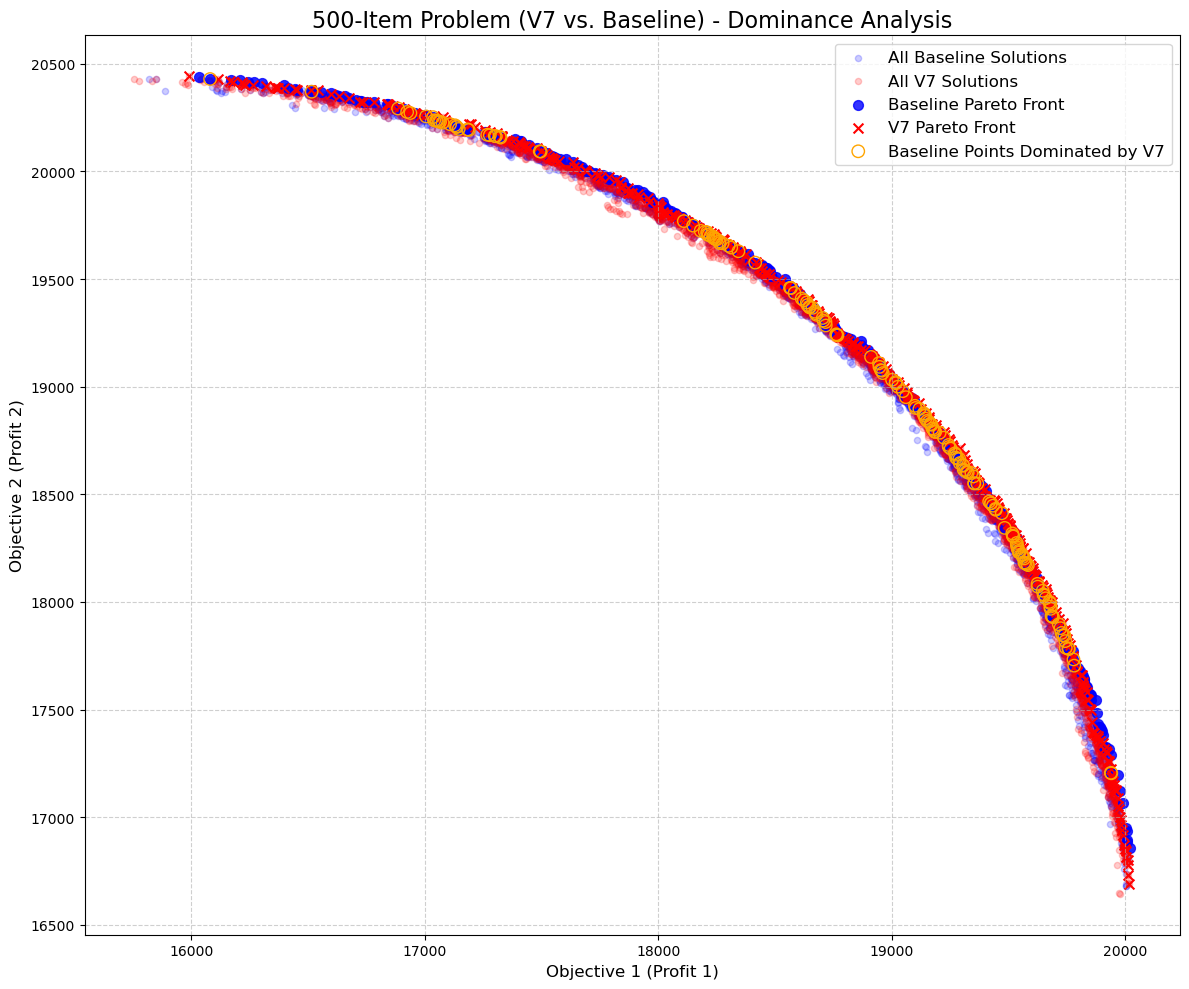

In [14]:
# =========================================================================
# ADVANCED ANALYSIS: DOMINANCE BETWEEN V7 AND BASELINE
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def analyze_dominance(baseline_file, v7_file, title):
    """
    Analyze the dominance relationship between two Pareto fronts.
    """
    print(f"\n--- Advanced Analysis: {title} ---")
    
    # Load data
    baseline_points = []
    with open(baseline_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    baseline_points.append([float(x) for x in line.split()])
                except ValueError: pass

    v7_points = []
    with open(v7_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    v7_points.append([float(x) for x in line.split()])
                except ValueError: pass
    
    baseline_pareto = get_true_pareto_front(baseline_points)
    v7_pareto = get_true_pareto_front(v7_points)

    # Calculate dominance
    dominated_baseline_count = 0
    dominated_v7_count = 0
    
    for b_point in baseline_pareto:
        for v_point in v7_pareto:
            if dominates(v_point, b_point):
                dominated_baseline_count += 1
                break # This baseline point is dominated, move to the next
                
    for v_point in v7_pareto:
        for b_point in baseline_pareto:
            if dominates(b_point, v_point):
                dominated_v7_count += 1
                break # This v7 point is dominated, move to the next

    # Calculate percentages
    percent_baseline_dominated = (dominated_baseline_count / len(baseline_pareto)) * 100 if baseline_pareto else 0
    percent_v7_dominated = (dominated_v7_count / len(v7_pareto)) * 100 if v7_pareto else 0
    
    print(f"  Baseline Pareto Front Size: {len(baseline_pareto)}")
    print(f"  V7 Pareto Front Size: {len(v7_pareto)}")
    print(f"  -------------------------------------------------")
    print(f"  Baseline points dominated by V7: {dominated_baseline_count} / {len(baseline_pareto)} ({percent_baseline_dominated:.2f}%)")
    print(f"  V7 points dominated by Baseline: {dominated_v7_count} / {len(v7_pareto)} ({percent_v7_dominated:.2f}%)")
    print(f"  -------------------------------------------------")

    # Plotting
    plt.figure(figsize=(12, 10))
    
    # Plot all points
    bx, by = zip(*baseline_points)
    vx, vy = zip(*v7_points)
    plt.scatter(bx, by, color='blue', alpha=0.2, s=20, label="All Baseline Solutions")
    plt.scatter(vx, vy, color='red', alpha=0.2, s=20, label="All V7 Solutions")

    # Plot Pareto fronts
    bx_p, by_p = zip(*baseline_pareto)
    vx_p, vy_p = zip(*v7_pareto)
    plt.scatter(bx_p, by_p, color='blue', alpha=0.8, s=50, label="Baseline Pareto Front")
    plt.scatter(vx_p, vy_p, color='red', marker='x', s=50, label="V7 Pareto Front")

    # Highlight dominated points
    dominated_b_points = []
    for b_point in baseline_pareto:
        for v_point in v7_pareto:
            if dominates(v_point, b_point):
                dominated_b_points.append(b_point)
                break
    if dominated_b_points:
        dbx, dby = zip(*dominated_b_points)
        plt.scatter(dbx, dby, color='orange', s=80, marker='o', facecolors='none', label="Baseline Points Dominated by V7")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Dominance Analysis", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
print("Starting advanced dominance analysis: Baseline vs. V7...")

# Make sure you use the correct V7 filename
analyze_dominance(
    "5002_ResultsMD.txt", 
    "5002_Results_Strategist_v7.txt", # <-- USE YOUR V7 FILENAME
    "500-Item Problem (V7 vs. Baseline)"
)

In [15]:
# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_efficient_llm_moacp_v5(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Strategist_v7.txt")
print("Finished experiment for 750 items.")
print("======================================================")
print("- 7502_Results_Strategist_v7.txt")


Starting experiment for 750 items...

--- RUN 1/10 ---
Instance: 750.2.txt, Items: 750, Objectives: 2
  [Problem Features] {
    "num_items": 750,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 703.64,
    "avg_weight_variance": 687.3
}
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Decision] Strategy: MODERATE, L: 5
  [LLM Reasoning] The problem has a moderate number of items (750) and multiple objectives (2). The high average profit variance (703.64) suggests that the problem is complex and may require some exploration to find good solutions. However, the relatively low capacity tightness (1.0) means that there are still many feasible solutions to consider. Therefore, a moderate L value of 5 should provide a good balance between exploration and exploitation.
  [Final Parameters] L=5, kappa=0.05
  [Intervention] Pausing at iteration 25 to consult LLM...
  [LLM Call] Sending prompt to llama3:latest...
  [

Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...

--- Analyzing 750-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 552
    Hypervolume: 56877706.67
  LLM-Strategist V6 (Adaptive):
    Pareto Front Size: 480 (-13.04%)
    Hypervolume: 56039786.25 (-1.47%)


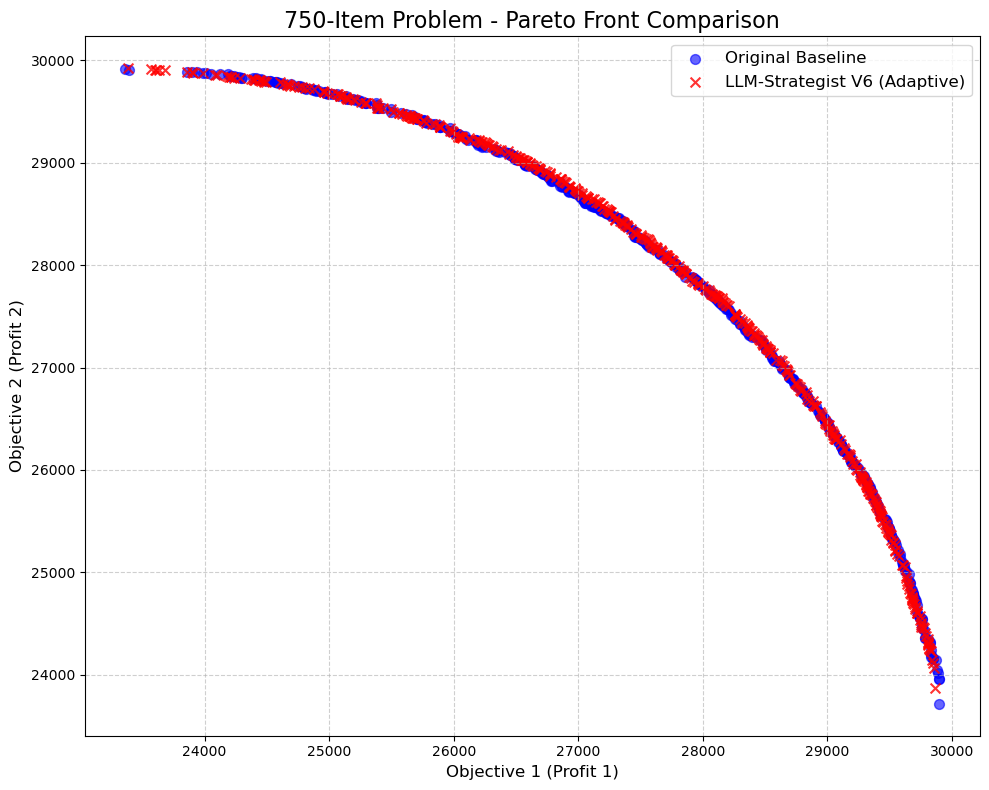


              SUMMARY OF IMPROVEMENTS (V7)

750-Item Problem:
  Hypervolume Improvement: -1.47%

--------------------------------------------------
  AVERAGE HV IMPROVEMENT: -1.47%
--------------------------------------------------

Analysis complete.


In [16]:
# --- MAIN EXECUTION ---
print("Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "7502_ResultsMD.txt",
        "strategist": "7502_Results_Strategist_v7.txt",
        "title": "750-Item Problem"
    },
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_strategist(
        files["original"], 
        files["strategist"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*50)
print("              SUMMARY OF IMPROVEMENTS (V7)")
print("="*50)

if all_results:
    total_hv_improvement = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        total_hv_improvement += res['hv_improvement']

    avg_hv_improvement = total_hv_improvement / len(all_results)
    
    print("\n" + "-"*50)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print("-"*50)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")

Starting advanced dominance analysis: Baseline vs. V7...

--- Advanced Analysis: 750-Item Problem (V7 vs. Baseline) ---
  Baseline Pareto Front Size: 552
  V7 Pareto Front Size: 480
  -------------------------------------------------
  Baseline points dominated by V7: 271 / 552 (49.09%)
  V7 points dominated by Baseline: 176 / 480 (36.67%)
  -------------------------------------------------


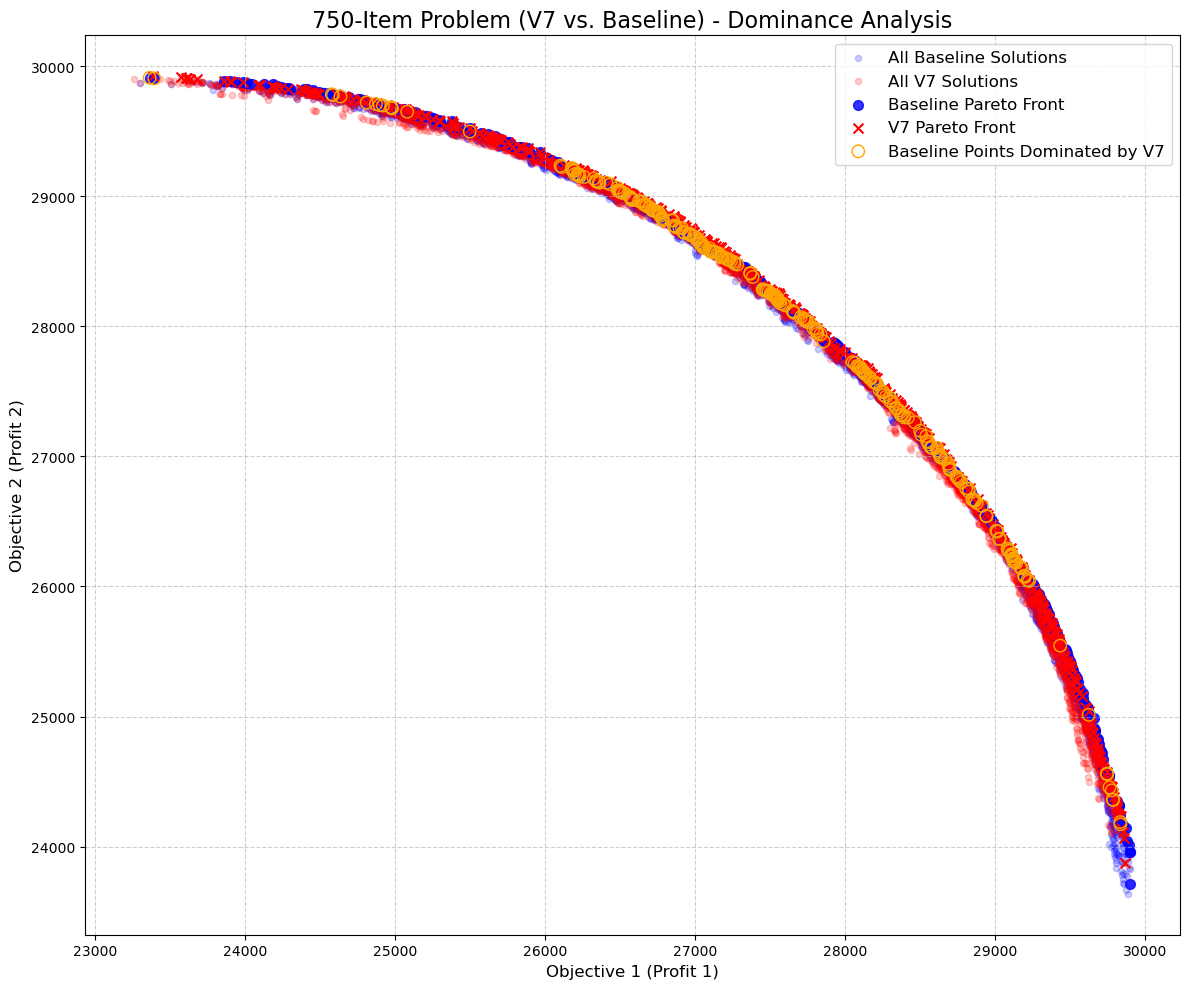

In [17]:
# =========================================================================
# ADVANCED ANALYSIS: DOMINANCE BETWEEN V7 AND BASELINE
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def analyze_dominance(baseline_file, v7_file, title):
    """
    Analyze the dominance relationship between two Pareto fronts.
    """
    print(f"\n--- Advanced Analysis: {title} ---")
    
    # Load data
    baseline_points = []
    with open(baseline_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    baseline_points.append([float(x) for x in line.split()])
                except ValueError: pass

    v7_points = []
    with open(v7_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    v7_points.append([float(x) for x in line.split()])
                except ValueError: pass
    
    baseline_pareto = get_true_pareto_front(baseline_points)
    v7_pareto = get_true_pareto_front(v7_points)

    # Calculate dominance
    dominated_baseline_count = 0
    dominated_v7_count = 0
    
    for b_point in baseline_pareto:
        for v_point in v7_pareto:
            if dominates(v_point, b_point):
                dominated_baseline_count += 1
                break # This baseline point is dominated, move to the next
                
    for v_point in v7_pareto:
        for b_point in baseline_pareto:
            if dominates(b_point, v_point):
                dominated_v7_count += 1
                break # This v7 point is dominated, move to the next

    # Calculate percentages
    percent_baseline_dominated = (dominated_baseline_count / len(baseline_pareto)) * 100 if baseline_pareto else 0
    percent_v7_dominated = (dominated_v7_count / len(v7_pareto)) * 100 if v7_pareto else 0
    
    print(f"  Baseline Pareto Front Size: {len(baseline_pareto)}")
    print(f"  V7 Pareto Front Size: {len(v7_pareto)}")
    print(f"  -------------------------------------------------")
    print(f"  Baseline points dominated by V7: {dominated_baseline_count} / {len(baseline_pareto)} ({percent_baseline_dominated:.2f}%)")
    print(f"  V7 points dominated by Baseline: {dominated_v7_count} / {len(v7_pareto)} ({percent_v7_dominated:.2f}%)")
    print(f"  -------------------------------------------------")

    # Plotting
    plt.figure(figsize=(12, 10))
    
    # Plot all points
    bx, by = zip(*baseline_points)
    vx, vy = zip(*v7_points)
    plt.scatter(bx, by, color='blue', alpha=0.2, s=20, label="All Baseline Solutions")
    plt.scatter(vx, vy, color='red', alpha=0.2, s=20, label="All V7 Solutions")

    # Plot Pareto fronts
    bx_p, by_p = zip(*baseline_pareto)
    vx_p, vy_p = zip(*v7_pareto)
    plt.scatter(bx_p, by_p, color='blue', alpha=0.8, s=50, label="Baseline Pareto Front")
    plt.scatter(vx_p, vy_p, color='red', marker='x', s=50, label="V7 Pareto Front")

    # Highlight dominated points
    dominated_b_points = []
    for b_point in baseline_pareto:
        for v_point in v7_pareto:
            if dominates(v_point, b_point):
                dominated_b_points.append(b_point)
                break
    if dominated_b_points:
        dbx, dby = zip(*dominated_b_points)
        plt.scatter(dbx, dby, color='orange', s=80, marker='o', facecolors='none', label="Baseline Points Dominated by V7")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Dominance Analysis", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
print("Starting advanced dominance analysis: Baseline vs. V7...")

# Make sure you use the correct V7 filename
analyze_dominance(
    "7502_ResultsMD.txt", 
    "7502_Results_Strategist_v7.txt", # <-- USE YOUR V7 FILENAME
    "750-Item Problem (V7 vs. Baseline)"
)

In [6]:
# =========================================================================
# PART 6: RUN THE EFFICIENT EXPERIMENTS (V4)
# =========================================================================

print("Running Efficient LLM-MOACP V4 on test instances...")
print("This version is optimized for efficiency with minimal LLM calls.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_efficient_llm_moacp_v5(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_Strategist_v7.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_efficient_llm_moacp_v5(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Strategist_v7.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_efficient_llm_moacp_v5(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Strategist_v7.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll efficient experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_Strategist_v7.txt")
print("- 5002_Results_Strategist_v7.txt")
print("- 7502_Results_Strategist_v7.txt")
print("\nYou can now run the analysis cells to compare the new results.")

Running Efficient LLM-MOACP V4 on test instances...
This version is optimized for efficiency with minimal LLM calls.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 745.59,
    "avg_weight_variance": 693.31
}
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Decision] Strategy: FOCUSED, L: 2
  [LLM Reasoning] Low capacity tightness and low variance in both profit and weight suggest a focused approach to avoid missing good local optima.
  [Final Parameters] L=2, kappa=0.05
  [Intervention] Pausing at iteration 25 to consult LLM...
  [LLM Call] Sending prompt to llama3:latest...
  [LLM Success] Received valid JSON.
  [LLM Adaptive Decision V6.1] Iteration 25: New L=3
  [LLM Reasoning] The hypervolume has increased significantly, which is great! However, the diversity

In [ ]:
# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_efficient_llm_moacp_v5(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Strategist_v7.txt")
print("Finished experiment for 750 items.")
print("======================================================")

Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...

--- Analyzing 250-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 212
    Hypervolume: 6614986.88
  LLM-Strategist V6 (Adaptive):
    Pareto Front Size: 216 (+1.89%)
    Hypervolume: 6754690.96 (+2.11%)


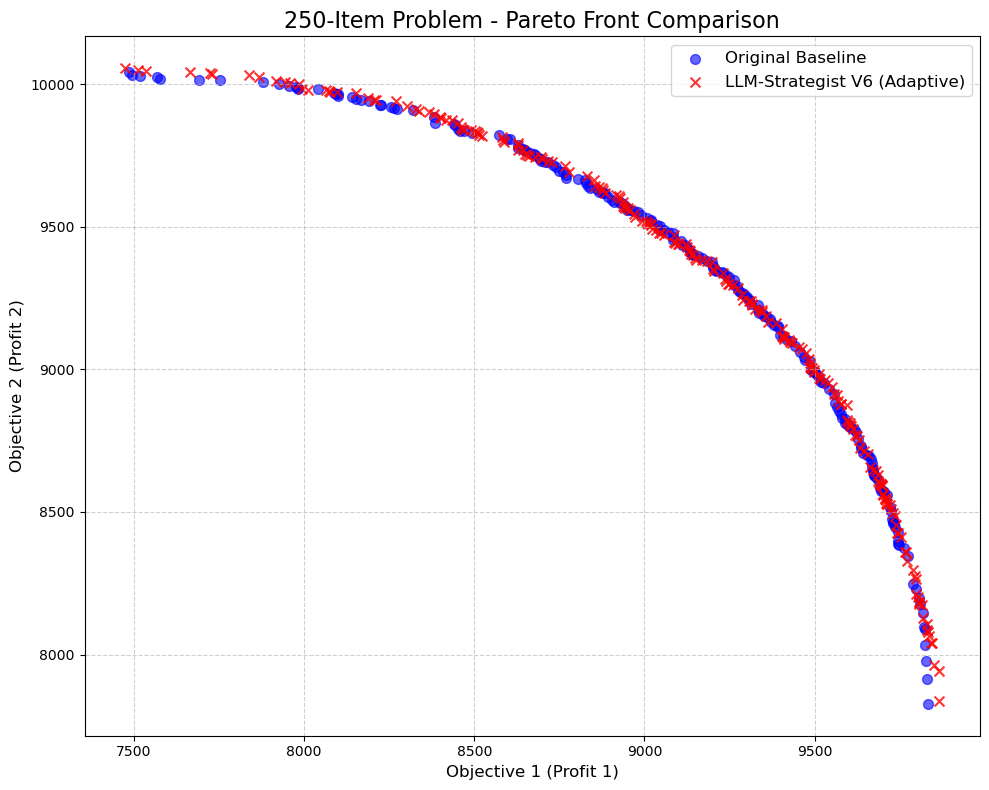


--- Analyzing 500-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 369
    Hypervolume: 23044962.94
  LLM-Strategist V6 (Adaptive):
    Pareto Front Size: 361 (-2.17%)
    Hypervolume: 23899551.64 (+3.71%)


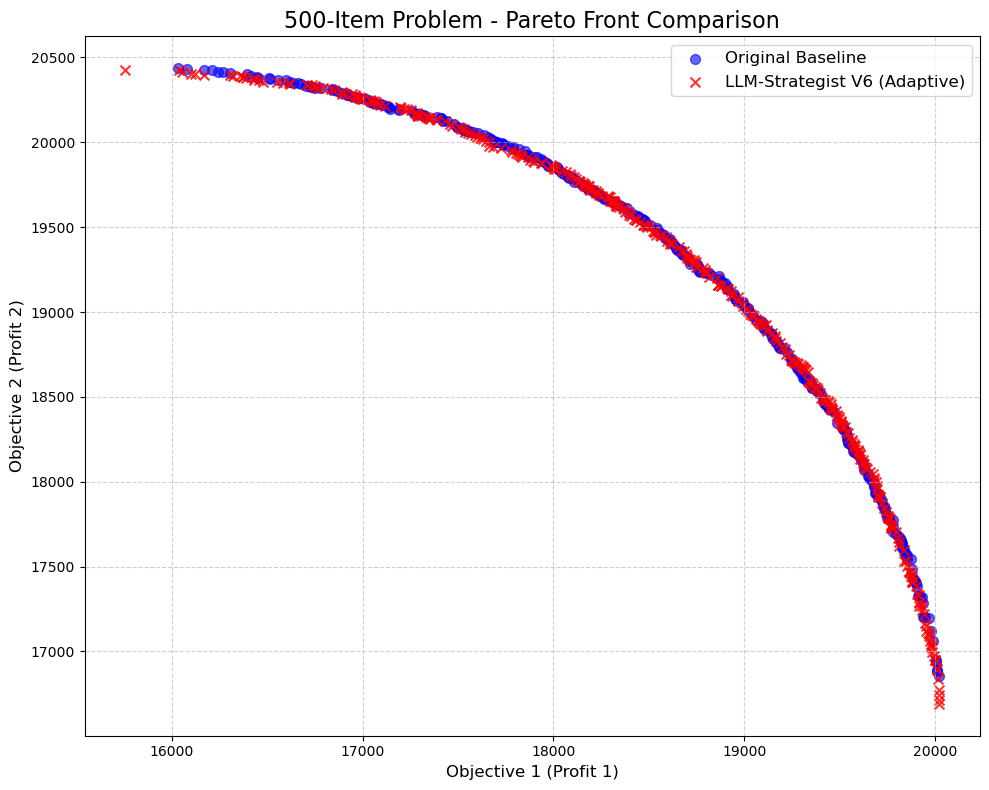


--- Analyzing 750-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 552
    Hypervolume: 56877706.67
  LLM-Strategist V6 (Adaptive):
    Pareto Front Size: 523 (-5.25%)
    Hypervolume: 57161384.67 (+0.50%)


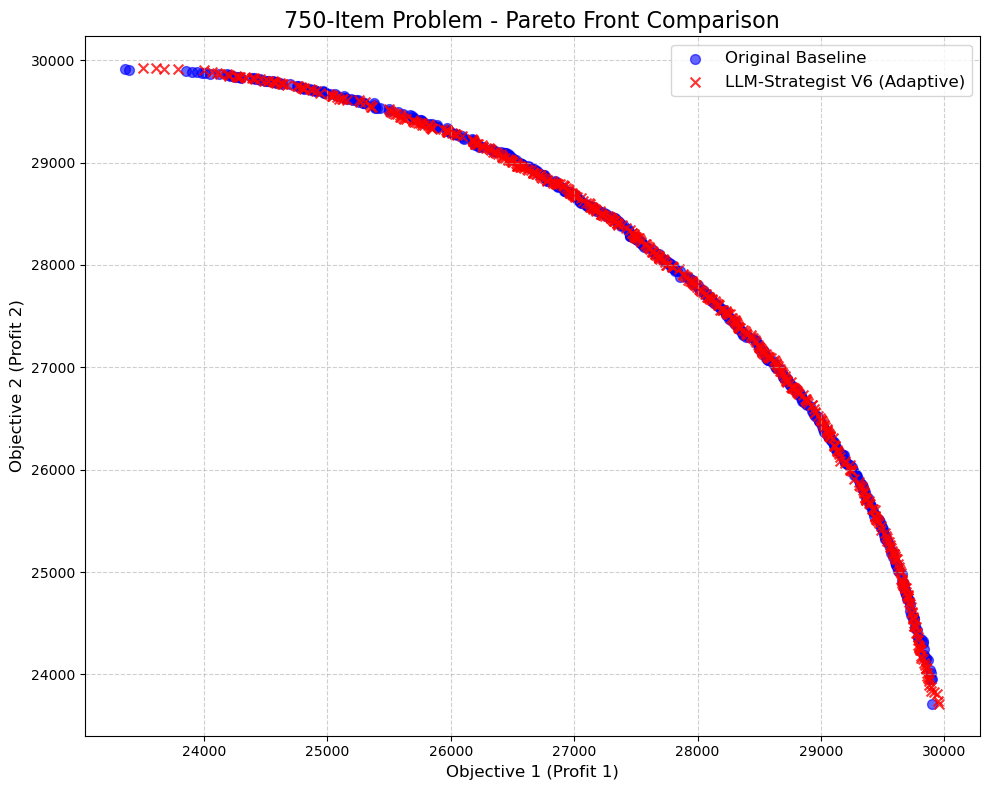


              SUMMARY OF IMPROVEMENTS (V6)

250-Item Problem:
  Hypervolume Improvement: +2.11%

500-Item Problem:
  Hypervolume Improvement: +3.71%

750-Item Problem:
  Hypervolume Improvement: +0.50%

--------------------------------------------------
  AVERAGE HV IMPROVEMENT: +2.11%
--------------------------------------------------

Analysis complete.


In [8]:
# =========================================================================
# PART 7: RESULTS COMPARISON AND ANALYSIS (Fixed for V6)
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    # Find a reference point that is slightly worse than the worst point in all objectives
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    # Sort points by the first objective to calculate the area under the curve
    sorted_points = sorted(points, key=lambda p: p[0])
    
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        # Area of the rectangle between two points on the front
        hv += (x2 - x1) * (ref_y - y1)
    
    # Add the area of the last rectangle to the reference point
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_baseline_vs_strategist(original_file, strategist_v6_file, title):
    """
    Compare the original baseline results with the new LLM-Strategist V6 results.
    """
    print(f"\n--- Analyzing {title} ---")
    
    # --- Load and Process Original Results ---
    original_points = []
    try:
        with open(original_file, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    try:
                        original_points.append([float(x) for x in line.split()])
                    except ValueError:
                        pass # Skip malformed lines
    except FileNotFoundError:
        print(f"  [ERROR] Original file not found: {original_file}")
        return None

    # --- Load and Process Strategist V6 Results ---
    strategist_v6_points = []
    try:
        with open(strategist_v6_file, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    try:
                        strategist_v6_points.append([float(x) for x in line.split()])
                    except ValueError:
                        pass # Skip malformed lines
    except FileNotFoundError:
        print(f"  [ERROR] Strategist V6 file not found: {strategist_v6_file}")
        return None

    # --- Calculate Pareto Fronts and Metrics ---
    original_pareto = get_true_pareto_front(original_points)
    strategist_v6_pareto = get_true_pareto_front(strategist_v6_points)
    
    original_size = len(original_pareto)
    strategist_v6_size = len(strategist_v6_pareto)
    
    original_hv = calculate_hypervolume(original_pareto)
    strategist_v6_hv = calculate_hypervolume(strategist_v6_pareto)
    
    # --- Calculate Percentage Improvements ---
    size_improvement = (strategist_v6_size - original_size) / original_size * 100 if original_size > 0 else 0
    hv_improvement = (strategist_v6_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    # --- Print Results ---
    print(f"  Original Algorithm:")
    print(f"    Pareto Front Size: {original_size}")
    print(f"    Hypervolume: {original_hv:.2f}")
    print(f"  LLM-Strategist V6 (Adaptive):")
    print(f"    Pareto Front Size: {strategist_v6_size} ({size_improvement:+.2f}%)")
    print(f"    Hypervolume: {strategist_v6_hv:.2f} ({hv_improvement:+.2f}%)")
    
    # --- Plotting ---
    plt.figure(figsize=(10, 8))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Baseline")
    if strategist_v6_pareto:
        sx, sy = zip(*strategist_v6_pareto)
        plt.scatter(sx, sy, color='red', marker='x', s=50, alpha=0.8, label="LLM-Strategist V6 (Adaptive)")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "title": title,
        "original_size": original_size,
        "strategist_v6_size": strategist_v6_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "strategist_v6_hv": strategist_v6_hv,
        "hv_improvement": hv_improvement
    }

# --- MAIN EXECUTION ---
print("Starting results analysis: Original Baseline vs. LLM-Strategist V6 (Adaptive)...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "2502_ResultsMD.txt",
        "strategist": "2502_Results_Strategist_v6.1.txt",
        "title": "250-Item Problem"
    },
    {
        "original": "5002_ResultsMD.txt",
        "strategist": "5002_Results_Strategist_v6.1.txt",
        "title": "500-Item Problem"
    },
    {
        "original": "7502_ResultsMD.txt",
        "strategist": "7502_Results_Strategist_v6.1.txt",
        "title": "750-Item Problem"
    }
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_strategist(
        files["original"], 
        files["strategist"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*50)
print("              SUMMARY OF IMPROVEMENTS (V6)")
print("="*50)

if all_results:
    total_hv_improvement = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        total_hv_improvement += res['hv_improvement']

    avg_hv_improvement = total_hv_improvement / len(all_results)
    
    print("\n" + "-"*50)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print("-"*50)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")

In [15]:
# Simple test to see if the module exists and can be imported
try:
    import optimized_moacp_cython
    print("✅ Module imported successfully.")
    print("Functions available:", dir(optimized_moacp_cython))
except ImportError as e:
    print(f"❌ ImportError: {e}")
except Exception as e:
    print(f"❌ Other error: {e}")

✅ Module imported successfully.
Functions available: ['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [10]:
import optimized_moacp_cython as omc
print(dir(omc))

['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [16]:
import optimized_moacp_cython as omc

for fn in [
    "set_alpha", "set_kappa", "set_L", "set_smallValue",
    "set_mutation_rate", "set_local_search_intensity",
    "set_greedy_bias", "set_repair_aggressiveness"
]:
    print(fn, hasattr(omc, fn))

set_alpha True
set_kappa True
set_L True
set_smallValue True
set_mutation_rate False
set_local_search_intensity False
set_greedy_bias False
set_repair_aggressiveness False
